# SHAP Analysis — Diabetes Risk Model

This notebook runs SHAP explainability analysis across all three trained models: 

- Decision Tree 
- Random Forest 
- XGBoost  

For each model it produces:

- **Summary plot** — beeswarm of SHAP values across the evaluation set
- **Bar plot** — mean |SHAP| feature importance
- **Waterfall plot** — local explanation for a single prediction
- **Feature importance CSV** — exportable ranking table

## 1. Imports & Configuration

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import shap

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.shap_analysis import ALL_MODELS, DATA_DIR, MODEL_LABELS, run_shap_analysis

shap.initjs()

In [2]:
OUTPUT_DIR = PROJECT_ROOT / "assets"
CSV_DIR = DATA_DIR

BACKGROUND_SIZE = 500
EVALUATION_SIZE = 1000
MAX_DISPLAY = 15
RANDOM_STATE = 42
WATERFALL_INDEX = 0
SKIP_WATERFALL = False

print("Configuration. Models to run:", list(ALL_MODELS))
print(f"Plots will be saved to: {OUTPUT_DIR}")
print(f"Feature-importance CSVs will be saved to: {CSV_DIR}")

Configuration. Models to run: ['decision_tree', 'random_forest', 'xgboost']
Plots will be saved to: C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\assets
Feature-importance CSVs will be saved to: C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\data


## 2. Shared SHAP Module

In [3]:
print("This notebook now reuses the shared SHAP helpers from src.shap_analysis.")

This notebook now reuses the shared SHAP helpers from src.shap_analysis.


## 3. Output Configuration

In [4]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

print(f"Assets directory ready: {OUTPUT_DIR}")
print(f"CSV directory ready: {CSV_DIR}")

Assets directory ready: C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\assets
CSV directory ready: C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\data


## 4. Run SHAP Analysis for all Models

Loops Through **Decision Tree, Random Forest and XGBoost** and for each model displays:

1. Feature importance table
2. Beeswarm summary plot
3. Bar plot
4. Waterfall plot(loacl explanation)


  DecisionTree
  Background rows: 500
  Evaluation rows: 1000


,feature,mean_abs_shap_predicted_class,mean_abs_shap_all_classes,mean_abs_shap_Gestational,mean_abs_shap_No Diabetes,mean_abs_shap_Pre-Diabetes,mean_abs_shap_Type 1,mean_abs_shap_Type 2
18,hba1c,0.3295,0.1520,0.0214,0.1112,0.2937,0.0157,0.3180
15,glucose_fasting,0.1092,0.0581,0.0032,0.1057,0.1183,0.0035,0.0597
0,Age,0.1031,0.0587,0.0804,0.0039,0.0385,0.0641,0.1064
24,gender,0.0429,0.0248,0.0569,0.0012,0.0129,0.0147,0.0382
23,income_level,0.0162,0.0099,0.0039,0.0023,0.0074,0.0227,0.0132
19,family_history_diabetes,0.0154,0.0079,0.0030,0.0063,0.0113,0.0006,0.0184
20,hypertension_history,0.0129,0.0073,0.0127,0.0008,0.0042,0.0048,0.0140
2,physical_activity_minutes_per_week,0.0109,0.0060,0.0072,0.0012,0.0021,0.0112,0.0083
9,diastolic_bp,0.0090,0.0052,0.0026,0.0007,0.0028,0.0102,0.0096
17,insulin_level,0.0077,0.0043,0.0065,0.0003,0.0032,0.0045,0.0068


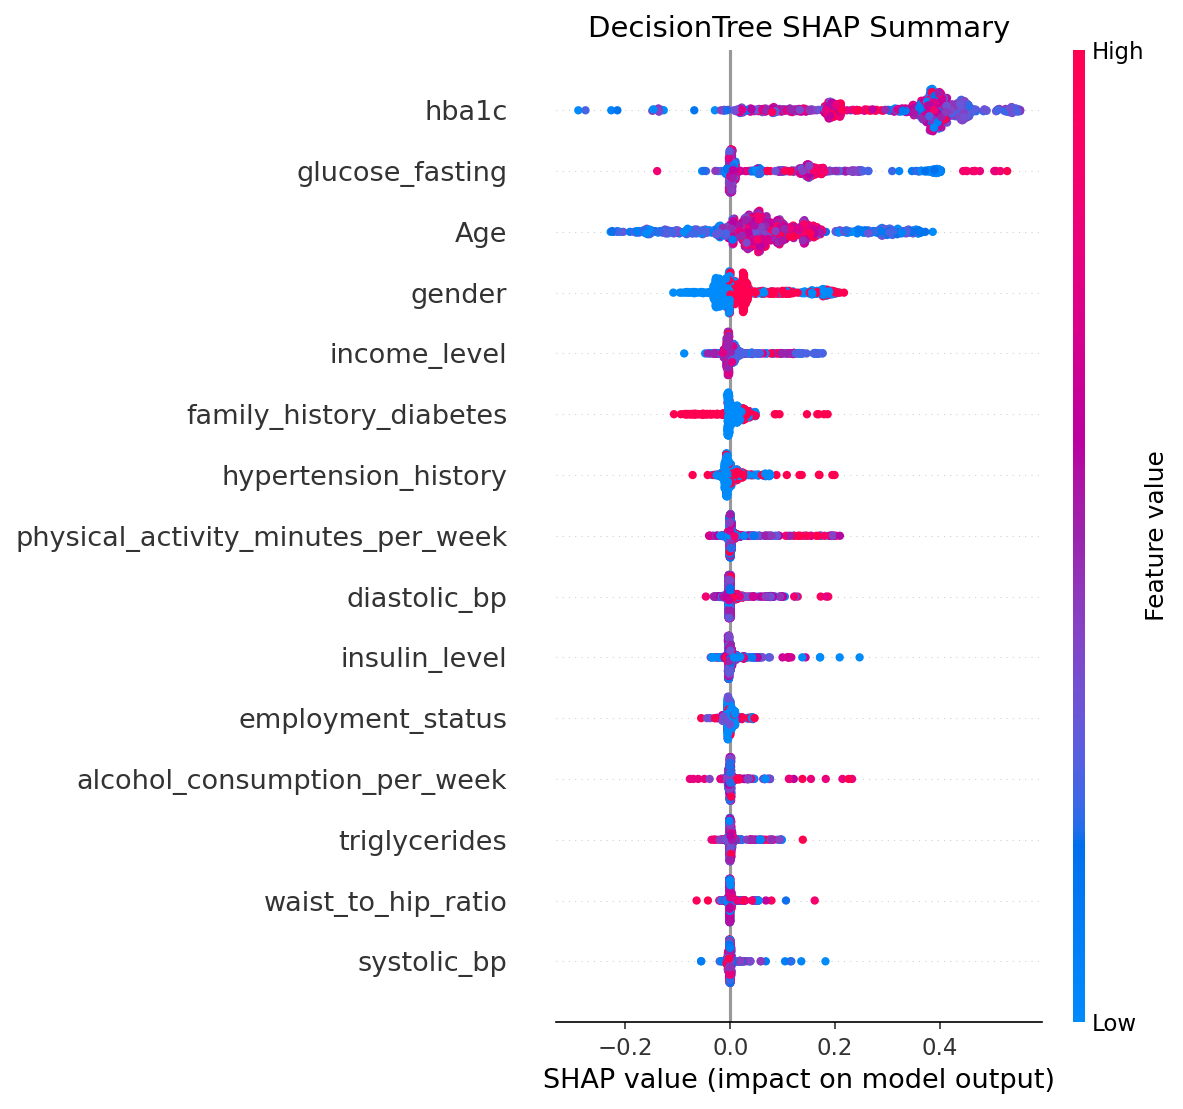

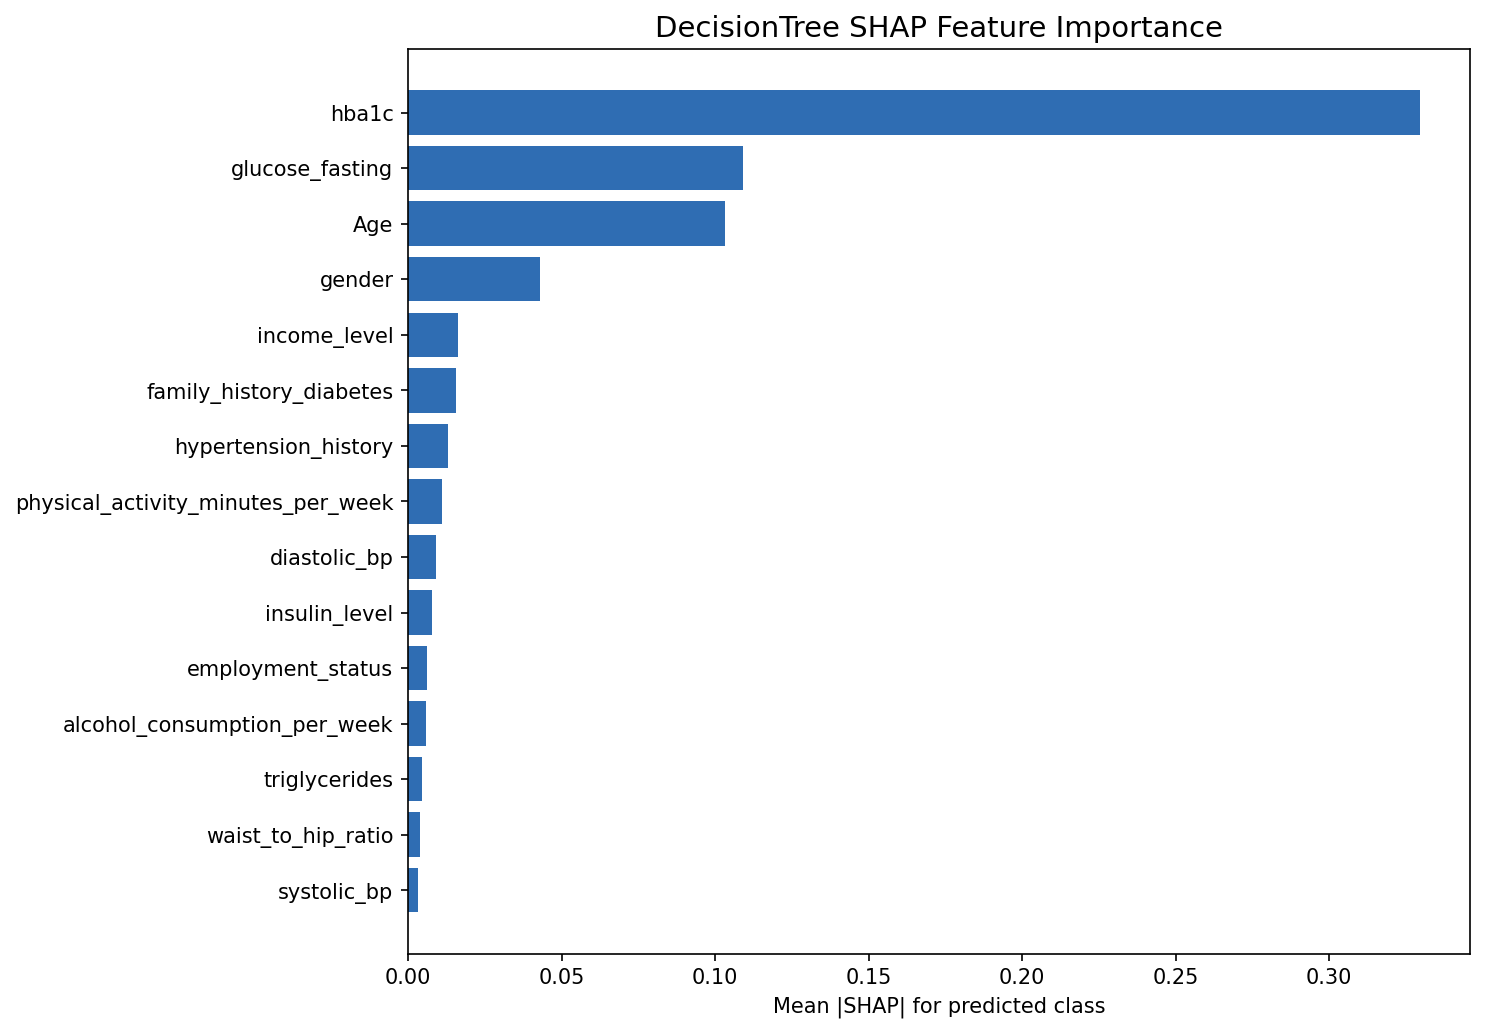

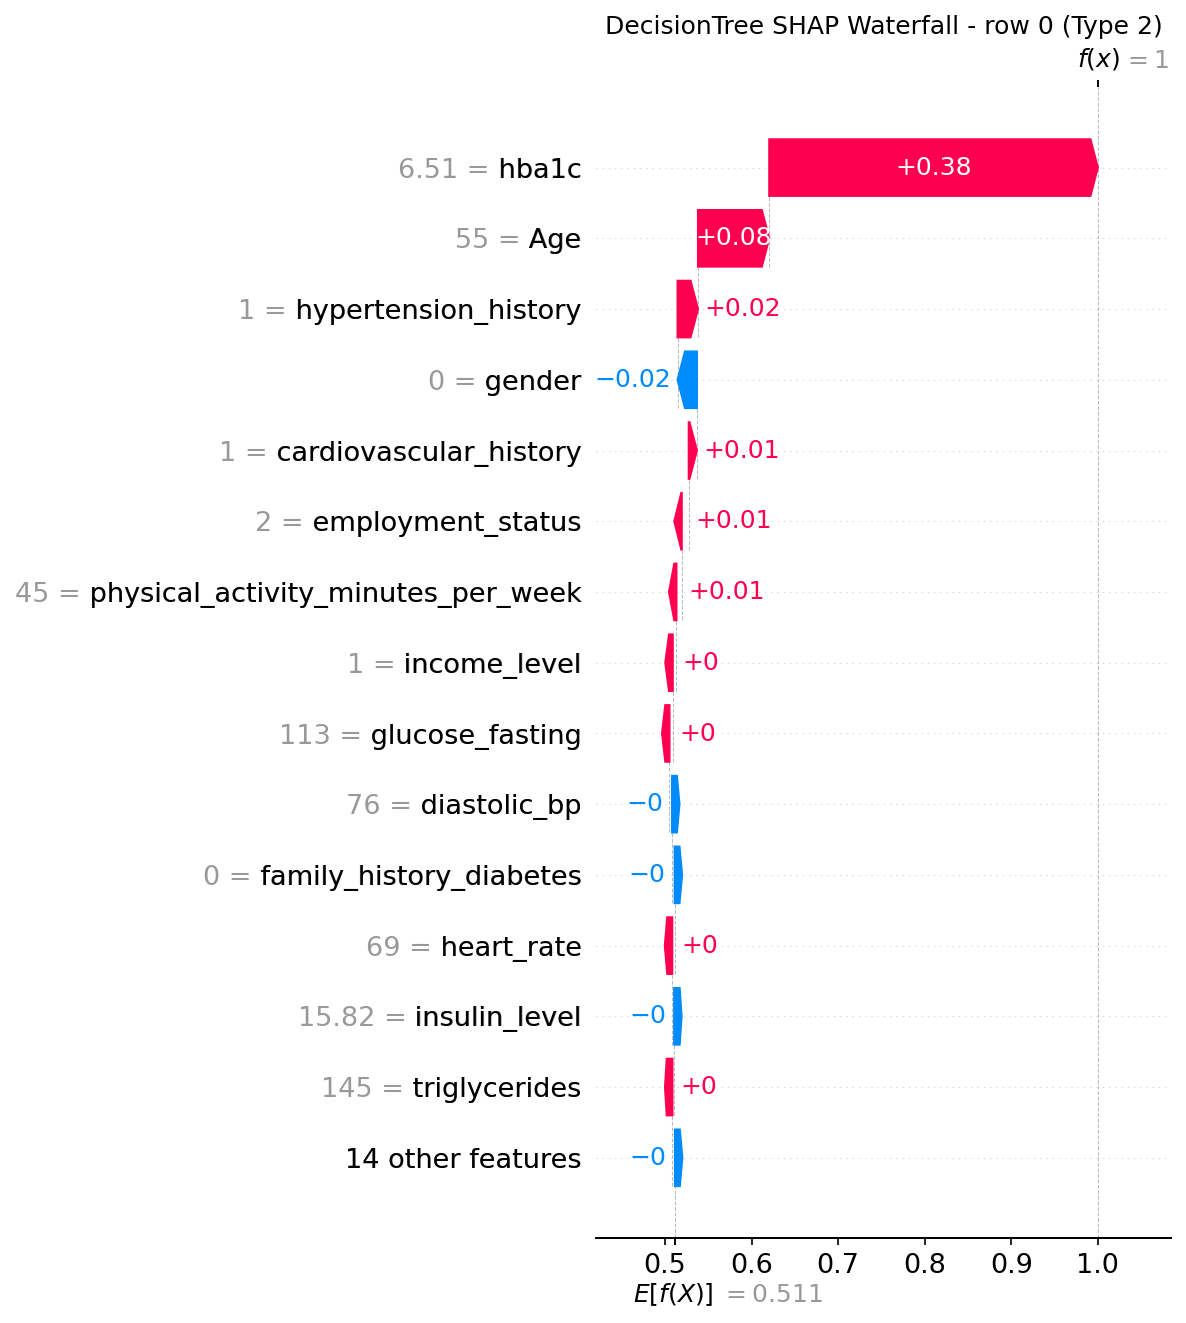

100%|===================| 4998/5000 [04:27<00:00]        


  RandomForest
  Background rows: 500
  Evaluation rows: 1000


,feature,mean_abs_shap_predicted_class,mean_abs_shap_all_classes,mean_abs_shap_Gestational,mean_abs_shap_No Diabetes,mean_abs_shap_Pre-Diabetes,mean_abs_shap_Type 1,mean_abs_shap_Type 2
18,hba1c,0.2936,0.1256,0.0095,0.1021,0.2395,0.0053,0.2717
15,glucose_fasting,0.0906,0.0452,0.0035,0.0910,0.0805,0.0031,0.0479
0,Age,0.0644,0.0367,0.0558,0.0019,0.0236,0.0348,0.0673
16,glucose_postprandial,0.0495,0.0231,0.0045,0.0172,0.0413,0.0023,0.0504
24,gender,0.0261,0.0160,0.0395,0.0011,0.0092,0.0050,0.0254
19,family_history_diabetes,0.0186,0.0097,0.0060,0.0052,0.0080,0.0054,0.0239
23,income_level,0.0091,0.0055,0.0030,0.0007,0.0049,0.0115,0.0076
8,systolic_bp,0.0080,0.0048,0.0036,0.0006,0.0028,0.0080,0.0092
20,hypertension_history,0.0065,0.0039,0.0057,0.0009,0.0017,0.0028,0.0086
26,employment_status,0.0045,0.0027,0.0026,0.0004,0.0017,0.0026,0.0062


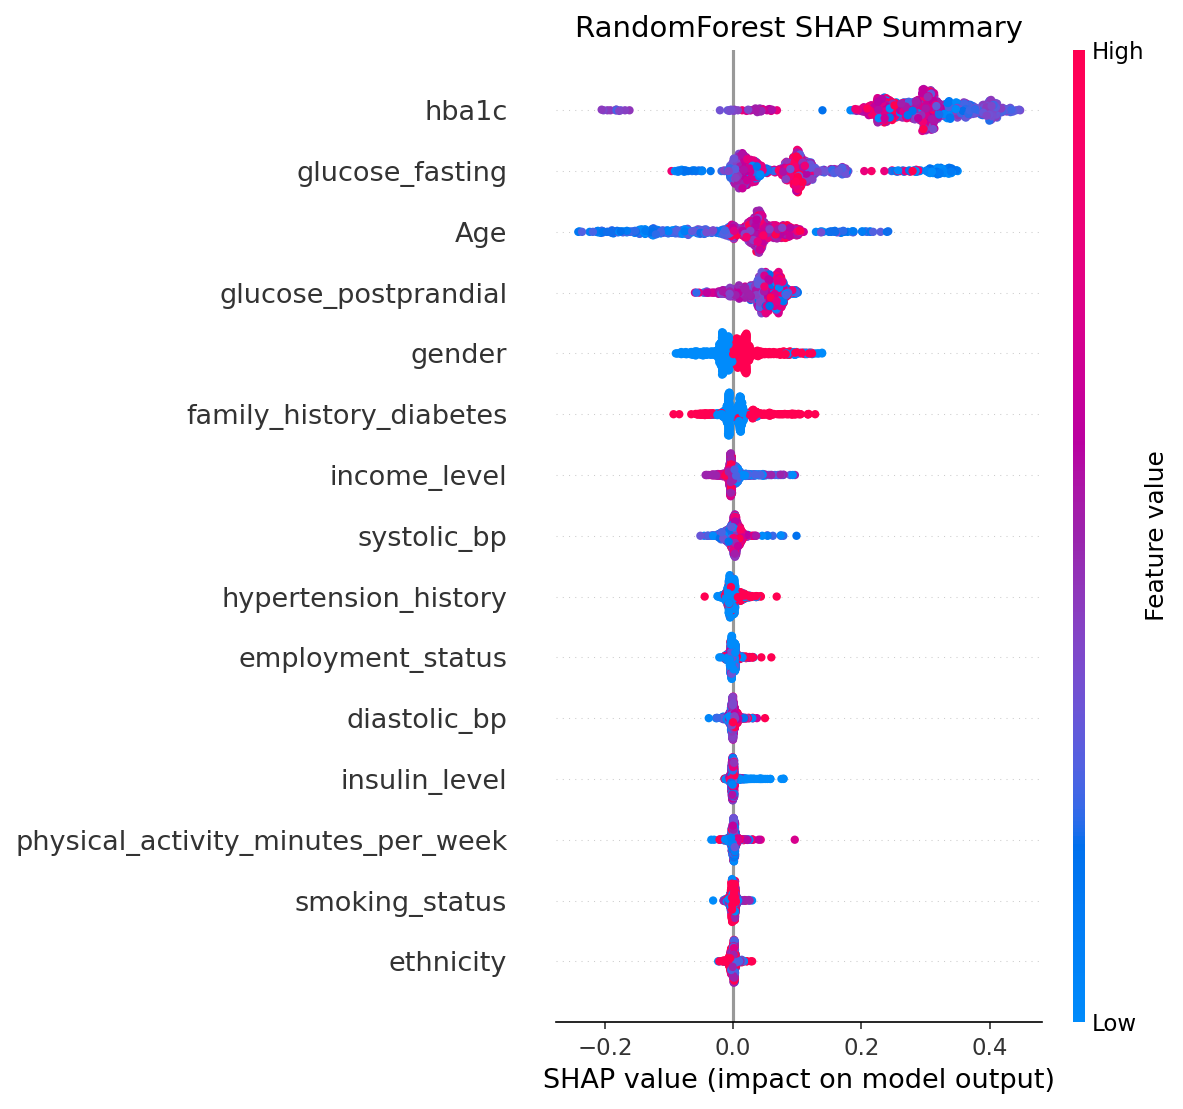

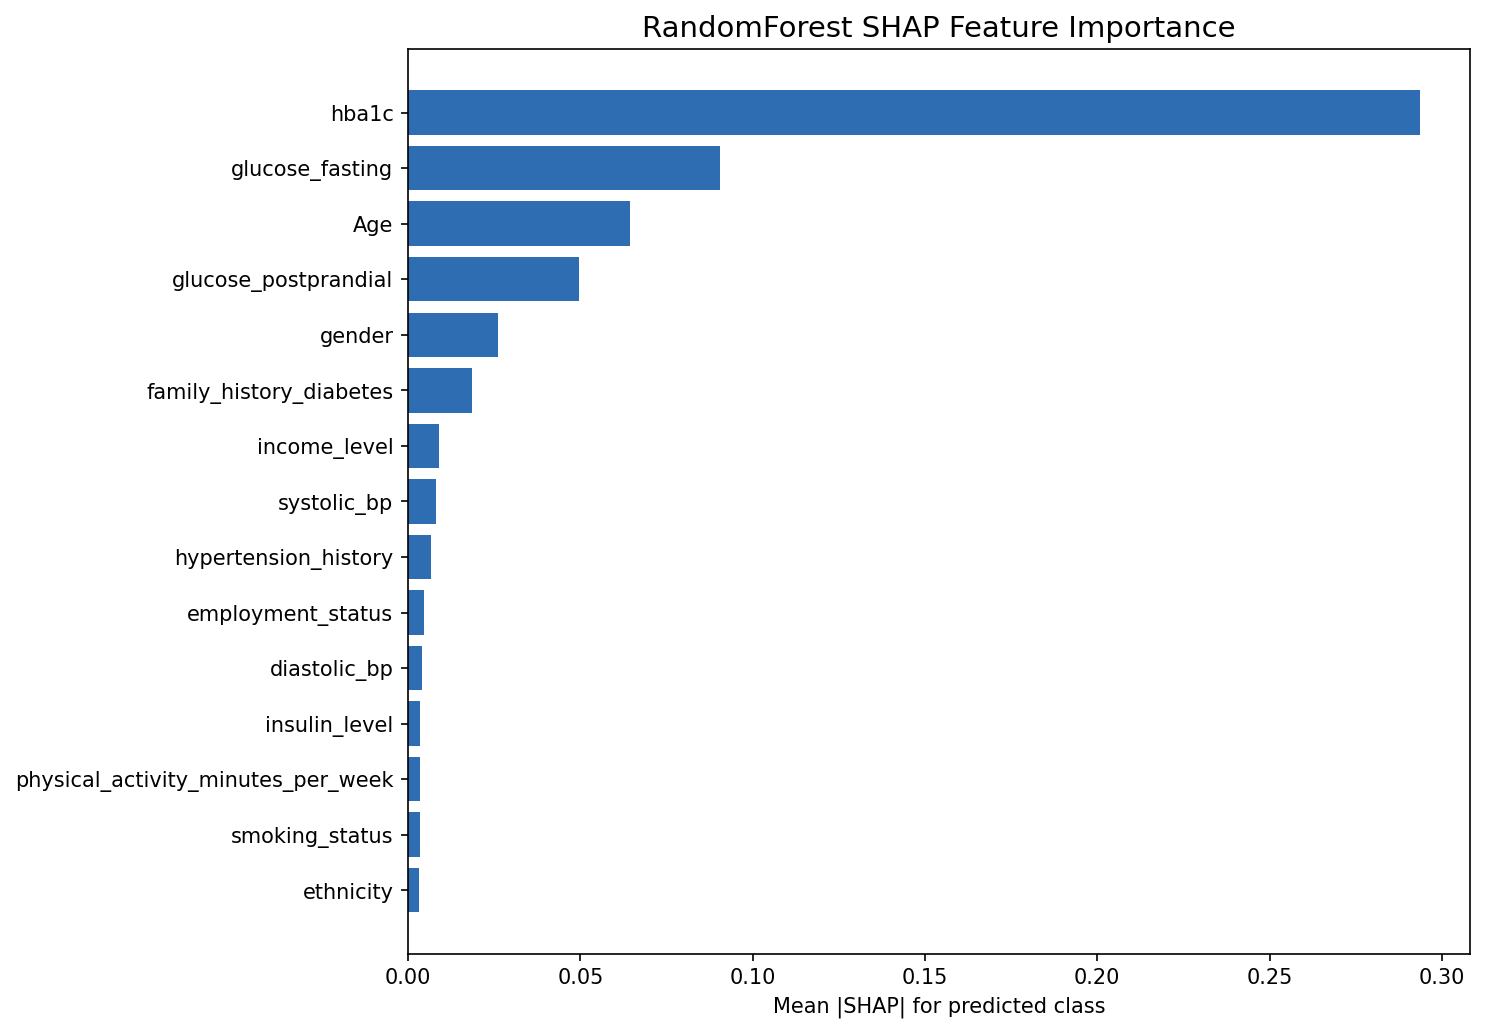

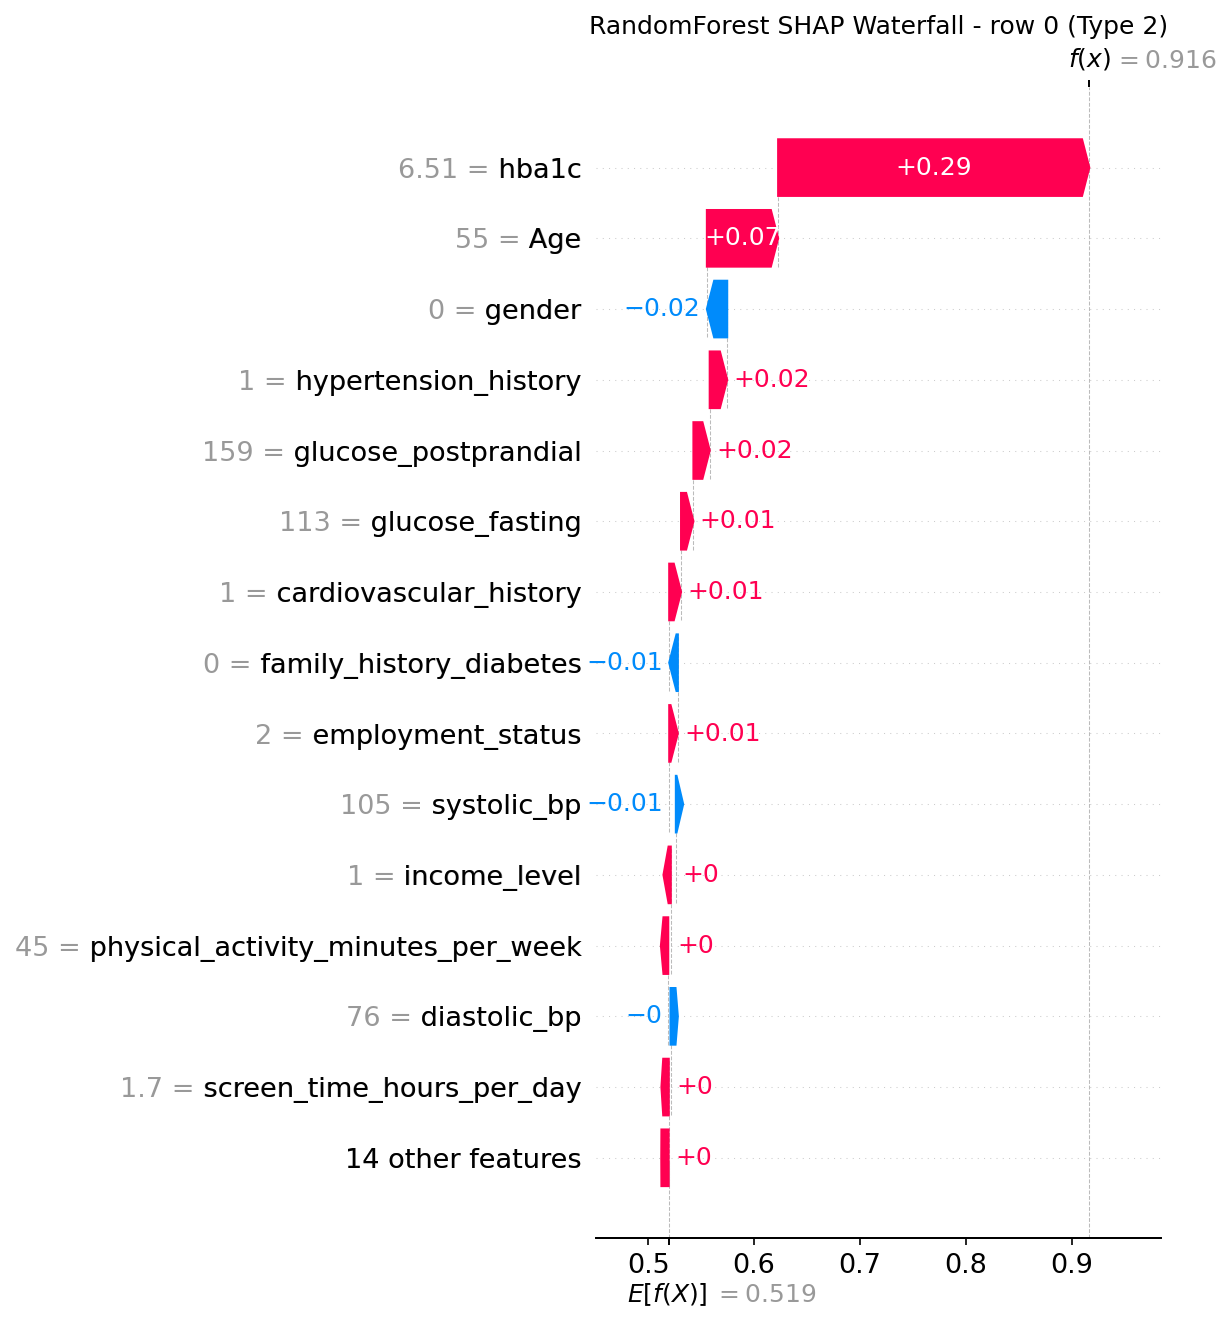

100%|===================| 4987/5000 [02:48<00:00]        


  XGBoost
  Background rows: 500
  Evaluation rows: 1000


,feature,mean_abs_shap_predicted_class,mean_abs_shap_all_classes,mean_abs_shap_Gestational,mean_abs_shap_No Diabetes,mean_abs_shap_Pre-Diabetes,mean_abs_shap_Type 1,mean_abs_shap_Type 2
18,hba1c,2.6973,1.2973,0.0851,1.3658,3.5200,0.0508,1.4647
15,glucose_fasting,0.8297,0.4873,0.0332,1.2174,0.8388,0.0427,0.3043
0,Age,0.4155,0.6386,1.3466,0.0195,0.0980,1.2309,0.4983
16,glucose_postprandial,0.2125,0.1382,0.0389,0.1983,0.1961,0.0534,0.2043
24,gender,0.1425,0.3608,1.6154,0.0041,0.0329,0.0425,0.1090
19,family_history_diabetes,0.1259,0.0764,0.0046,0.0614,0.0169,0.0706,0.2284
20,hypertension_history,0.1047,0.0731,0.1028,0.0177,0.0166,0.0675,0.1612
8,systolic_bp,0.0896,0.0909,0.0378,0.0087,0.0429,0.2668,0.0981
23,income_level,0.0865,0.0834,0.0179,0.0111,0.0263,0.2617,0.0999
4,sleep_hours_per_day,0.0860,0.0552,0.0335,0.0105,0.0215,0.0937,0.1167


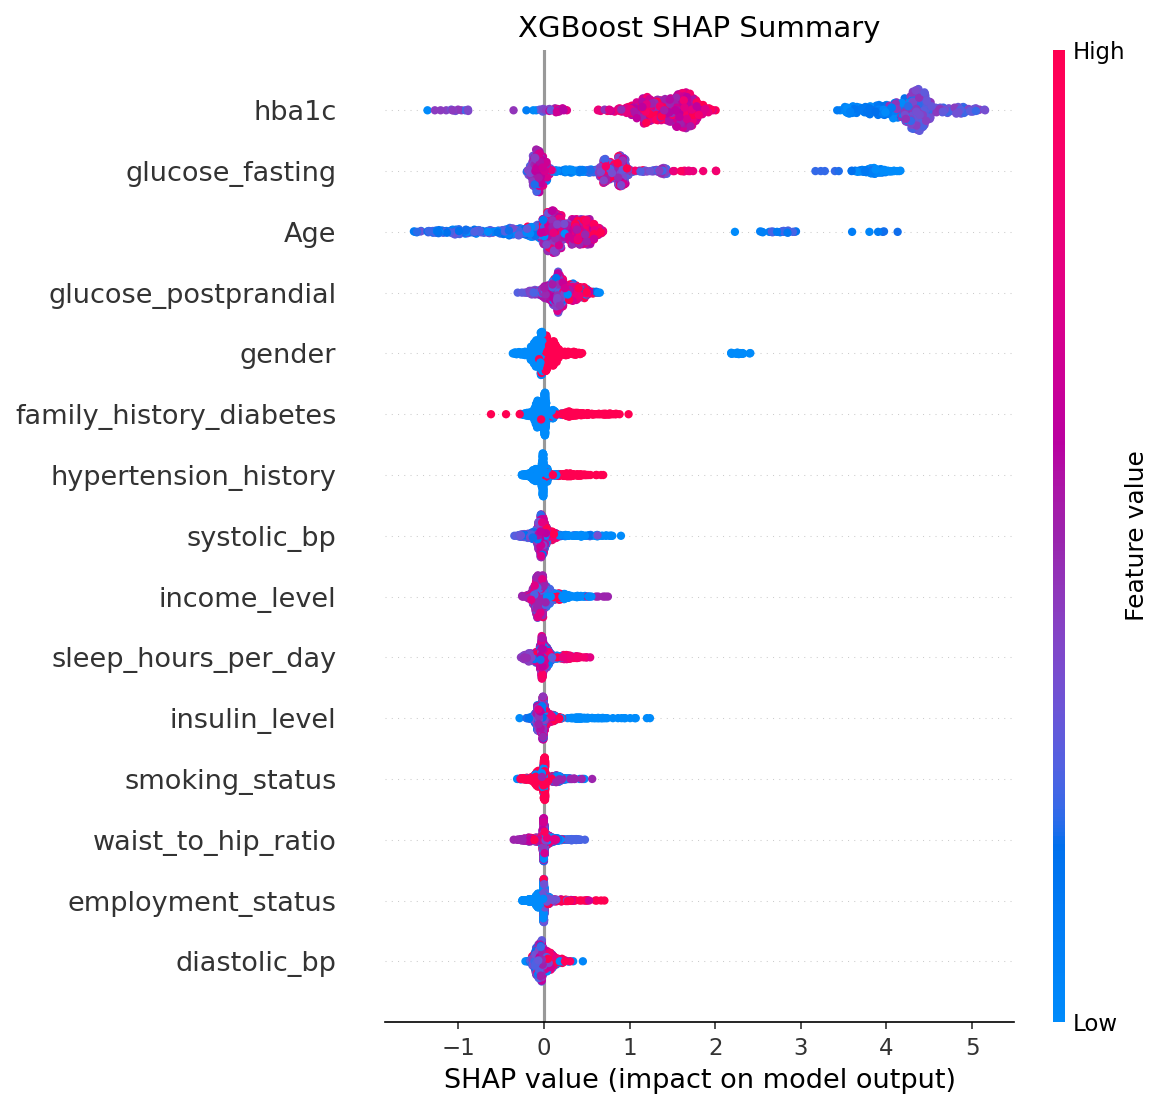

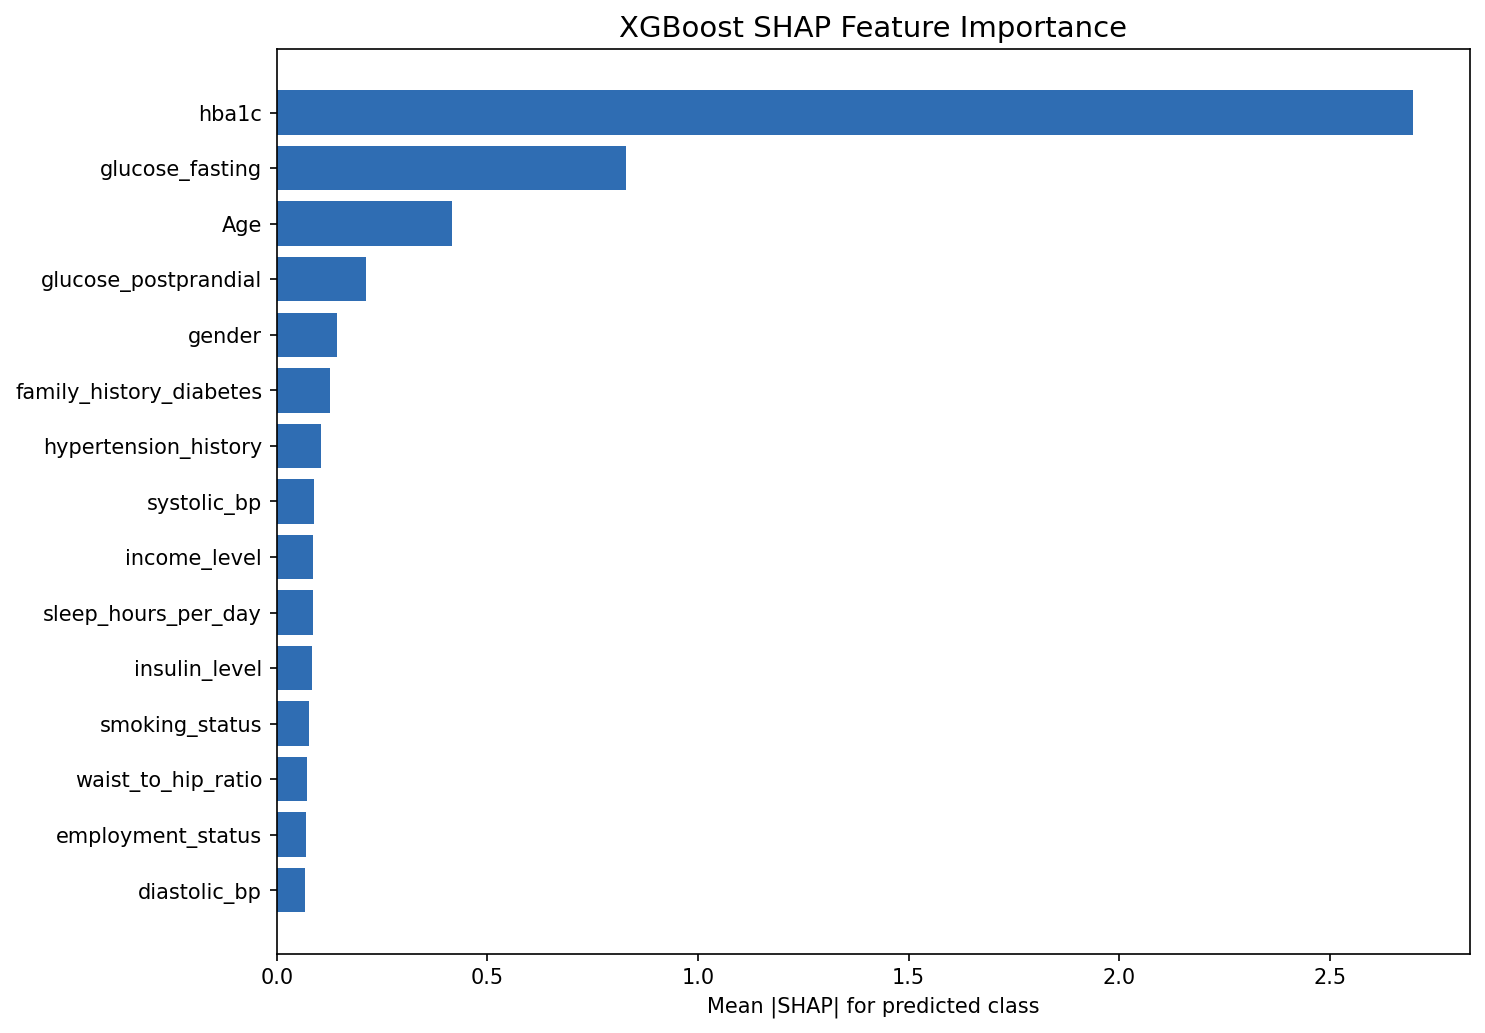

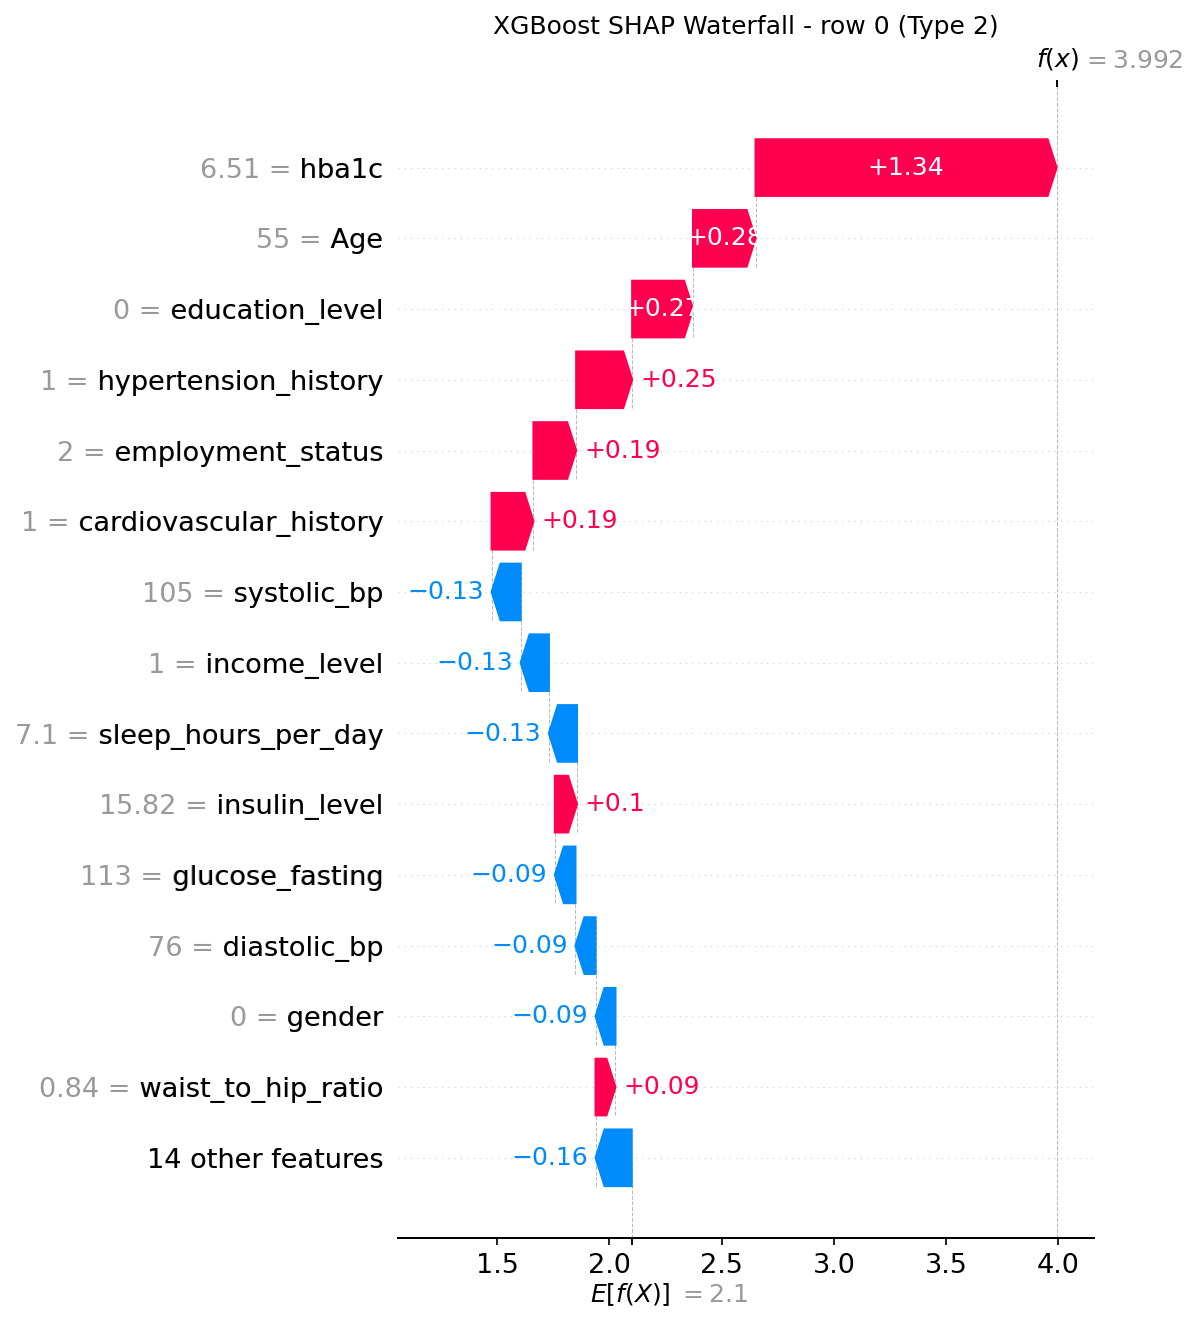


All models complete.


In [5]:
all_importance = {}

for model_name in ALL_MODELS:
    result = run_shap_analysis(
        model_name,
        background_size=BACKGROUND_SIZE,
        evaluation_size=EVALUATION_SIZE,
        max_display=MAX_DISPLAY,
        random_state=RANDOM_STATE,
        waterfall_index=WATERFALL_INDEX,
        skip_waterfall=SKIP_WATERFALL,
        output_dir=OUTPUT_DIR,
        csv_dir=CSV_DIR,
    )

    model_label = result["model_label"]
    importance_df = result["importance_df"]
    all_importance[model_name] = importance_df.copy()

    print("\n" + "=" * 60)
    print(f"  {model_label}")
    print("=" * 60)
    print(f"  Background rows: {result['background_rows']}")
    print(f"  Evaluation rows: {result['evaluation_rows']}")

    display(
        importance_df.head(MAX_DISPLAY)
        .style
        .set_caption(f"{model_label} — Feature Importance")
        .background_gradient(subset=["mean_abs_shap_predicted_class"], cmap="Blues")
        .format({c: "{:.4f}" for c in importance_df.columns if c != "feature"})
    )

    display(Image(filename=str(result["summary_path"])))
    display(Image(filename=str(result["bar_path"])))
    if result["waterfall_path"] is not None:
        display(Image(filename=str(result["waterfall_path"])))

print("\nAll models complete.")

## 5. Side-by-Side Feature Importance Comparison

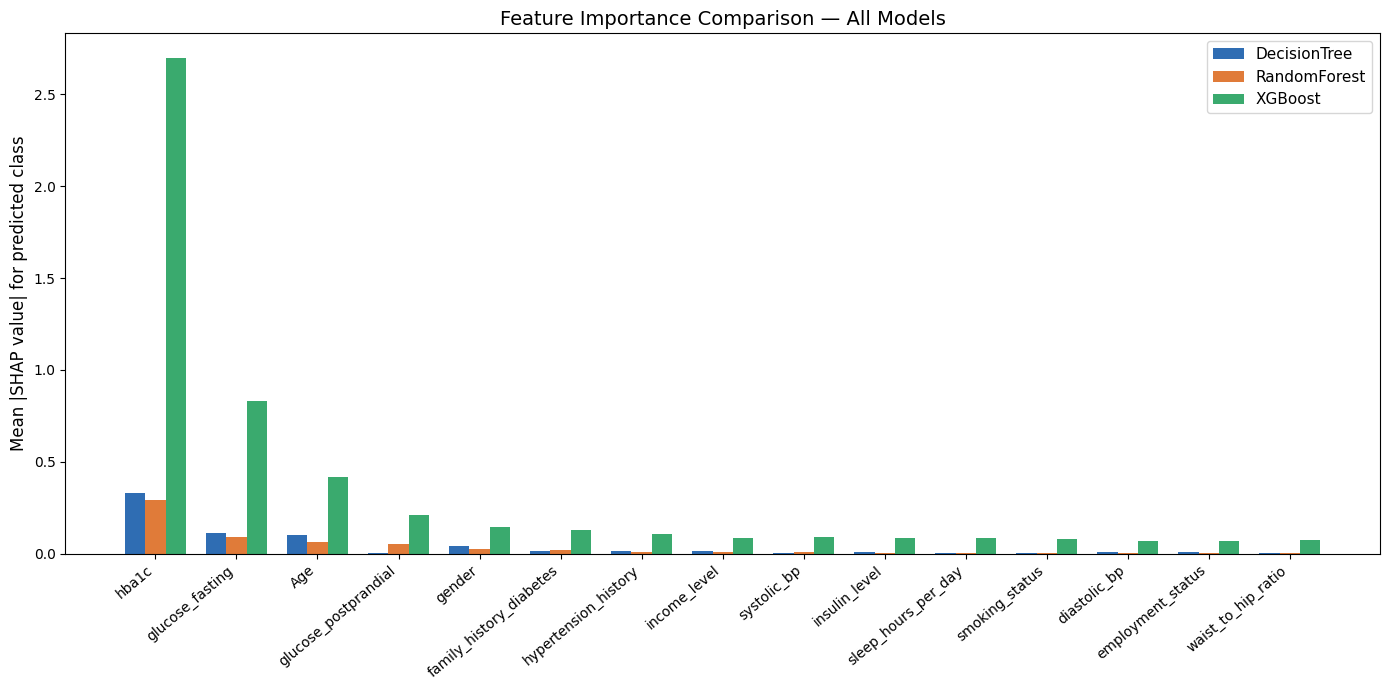

Saved: C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\assets\all_models_shap_comparison.png


In [6]:
# Build merged comparison dataframe
comparison = None
for model_name, imp_df in all_importance.items():
    label = MODEL_LABELS[model_name]
    col   = imp_df[["feature", "mean_abs_shap_predicted_class"]].rename(
        columns={"mean_abs_shap_predicted_class": label}
    )
    comparison = col if comparison is None else comparison.merge(col, on="feature", how="outer")

comparison     = comparison.fillna(0)
label_cols     = [MODEL_LABELS[m] for m in ALL_MODELS]
comparison["avg_importance"] = comparison[label_cols].mean(axis=1)
comparison     = comparison.sort_values("avg_importance", ascending=False).head(MAX_DISPLAY)

# Grouped bar chart
x      = np.arange(len(comparison))
width  = 0.25
colors = ["#2f6db3", "#e07b39", "#3aaa6e"]

comparison_chart_path = OUTPUT_DIR / "all_models_shap_comparison.png"

fig, ax = plt.subplots(figsize=(14, 7))
for i, (label, color) in enumerate(zip(label_cols, colors)):
    ax.bar(x + i * width, comparison[label], width, label=label, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(comparison["feature"], rotation=40, ha="right", fontsize=10)
ax.set_ylabel("Mean |SHAP value| for predicted class", fontsize=12)
ax.set_title("Feature Importance Comparison — All Models", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(comparison_chart_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Saved: {comparison_chart_path}")

## 6. Comparison Table - Top Features by Model

In [7]:
display(
    comparison[["feature"] + label_cols + ["avg_importance"]]
    .reset_index(drop=True)
    .style
    .set_caption("Mean |SHAP| per model — top features ranked by average importance")
    .background_gradient(subset=label_cols + ["avg_importance"], cmap="YlOrRd")
    .format({c: "{:.4f}" for c in label_cols + ["avg_importance"]})
)

,feature,DecisionTree,RandomForest,XGBoost,avg_importance
0,hba1c,0.3295,0.2936,2.6973,1.1068
1,glucose_fasting,0.1092,0.0906,0.8297,0.3432
2,Age,0.1031,0.0644,0.4155,0.1943
3,glucose_postprandial,0.0023,0.0495,0.2125,0.0881
4,gender,0.0429,0.0261,0.1425,0.0705
5,family_history_diabetes,0.0154,0.0186,0.1259,0.0533
6,hypertension_history,0.0129,0.0065,0.1047,0.0414
7,income_level,0.0162,0.0091,0.0865,0.0372
8,systolic_bp,0.0033,0.0080,0.0896,0.0336
9,insulin_level,0.0077,0.0036,0.0849,0.0321


## 7. Summary

In [8]:
print("=" * 60)
print("  SHAP Analysis Complete")
print("=" * 60)
for model_name in ALL_MODELS:
    label = MODEL_LABELS[model_name]
    top   = all_importance[model_name].iloc[0]
    print(f"  {label:<15} → top feature: {top['feature']} ({top['mean_abs_shap_predicted_class']:.4f})")
print("-" * 60)
print(f"  Plots saved to : {OUTPUT_DIR}")
print(f"  CSVs saved to  : {CSV_DIR}")
print("=" * 60)

  SHAP Analysis Complete
  DecisionTree    → top feature: hba1c (0.3295)
  RandomForest    → top feature: hba1c (0.2936)
  XGBoost         → top feature: hba1c (2.6973)
------------------------------------------------------------
  Plots saved to : C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\assets
  CSVs saved to  : C:\Users\jandr\OneDrive\Documents\Beglium Campus Files\Year 3\MLG382\Projects\Project 1\Guided_Project_MLG382_2026\MLG382-Diabetes-DSS\data
